<a id='2'></a>
# <p style="padding: 8px;color:white; display:fill;background-color:#555555; border-radius:5px; font-size:100%"> <b>Import and Set up</b>

In [ ]:
import numpy as np
import pandas as pd

from IPython.core.display import display, HTML
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio


import seaborn as sns
from importlib import reload
import matplotlib.pyplot as plt
import matplotlib
import warnings



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/UNSW_NB15_training-set.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [ ]:
df.head(10)

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.09020,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.00030,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.00510,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.66080,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.00250,...,1,3,0,0,0,2,3,0,Normal,0
5,6,0.000003,udp,-,INT,2,0,784,0,333333.32150,...,1,2,0,0,0,2,2,0,Normal,0
6,7,0.000006,udp,-,INT,2,0,1960,0,166666.66080,...,1,2,0,0,0,2,2,0,Normal,0
7,8,0.000028,udp,-,INT,2,0,1384,0,35714.28522,...,1,3,0,0,0,1,3,0,Normal,0
8,9,0.000000,arp,-,INT,1,0,46,0,0.00000,...,2,2,0,0,0,2,2,1,Normal,0
9,10,0.000000,arp,-,INT,1,0,46,0,0.00000,...,2,2,0,0,0,2,2,1,Normal,0


In [ ]:
df.describe(include='all')

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
count,82332.000000,82332.000000,82332,82332,82332,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332,82332.000000
unique,NaN,NaN,131,13,7,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN
top,NaN,NaN,tcp,-,FIN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN
freq,NaN,NaN,43095,47153,39339,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37000,NaN
mean,41166.500000,1.006756,NaN,NaN,NaN,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,...,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,NaN,0.550600
std,23767.345519,4.710444,NaN,NaN,NaN,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,...,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,NaN,0.497436
min,1.000000,0.000000,NaN,NaN,NaN,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,NaN,0.000000
25%,20583.750000,0.000008,NaN,NaN,NaN,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,NaN,0.000000
50%,41166.500000,0.014138,NaN,NaN,NaN,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,...,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,NaN,1.000000
75%,61749.250000,0.719360,NaN,NaN,NaN,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,...,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,NaN,1.000000


<a id='3'></a>
# <p style="padding: 8px;color:white; display:fill;background-color:#555555; border-radius:5px; font-size:100%"> <b>Pre-processing and Feature Selection</b>

In [ ]:
list_drop = ['id','attack_cat']

In [ ]:
df.drop(list_drop,axis=1,inplace=True)

In [ ]:
# Clamp extreme Values
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.describe(include='all')

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,6.305470e+05,...,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,2.393001e+06,...,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,2.112951e+03,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,1.585808e+04,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,2.082111e+07,...,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


In [ ]:
DEBUG =0

for feature in df_numeric.columns:
    if DEBUG == 1:
        print(feature)
        print('max = '+str(df_numeric[feature].max()))
        print('75th = '+str(df_numeric[feature].quantile(0.95)))
        print('median = '+str(df_numeric[feature].median()))
        print(df_numeric[feature].max()>10*df_numeric[feature].median())
        print('----------------------------------------------------')
    if df_numeric[feature].max()>10*df_numeric[feature].median() and df_numeric[feature].max()>10 :
        df[feature] = np.where(df[feature]<df[feature].quantile(0.95), df[feature], df[feature].quantile(0.95))

In [ ]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.describe(include='all')

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.00000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,0.445016,11.84186,9.178424,1580.566135,2866.918367,71576.702810,180.967667,95.713003,4.649418e+07,3.105380e+05,...,4.466611,3.388901,7.160679,0.008284,0.008381,0.092066,5.974809,8.832532,0.011126,0.550600
std,0.672222,15.66461,14.504212,2948.850472,7525.606738,102631.946851,101.513358,116.667722,7.417784e+07,8.918691e+05,...,6.685037,5.029129,10.481621,0.091171,0.092485,0.289121,6.867156,10.124902,0.104891,0.497436
min,0.000000,1.00000,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000008,2.00000,0.000000,114.000000,0.000000,28.606114,62.000000,0.000000,1.120247e+04,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,0.014138,6.00000,2.000000,534.000000,178.000000,2650.176667,254.000000,29.000000,5.770032e+05,2.112951e+03,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,0.719360,12.00000,10.000000,1280.000000,956.000000,111111.107200,254.000000,252.000000,6.514286e+07,1.585808e+04,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,2.403792,60.00000,54.000000,12472.000000,30622.000000,333333.321500,255.000000,253.000000,2.666667e+08,3.741446e+06,...,25.000000,18.000000,37.000000,2.000000,2.000000,1.000000,25.000000,36.000000,1.000000,1.000000


## Apply log function to nearly all numeric, since they are all mostly skewed to the right

It would have been too much of a slog to apply the log function individually, therefore a simple rule has been set up: if the number of unique values in the continuous feature is more than 50 then apply the log function. The reason more than 50 unique values are sought is to filter out the integer based features that act more categorically.  

In [ ]:
df_numeric = df.select_dtypes(include=[np.number])
df_before = df_numeric.copy()
DEBUG = 0
for feature in df_numeric.columns:
    if DEBUG == 1:
        print(feature)
        print('nunique = '+str(df_numeric[feature].nunique()))
        print(df_numeric[feature].nunique()>50)
        print('----------------------------------------------------')
    if df_numeric[feature].nunique()>50:
        if df_numeric[feature].min()==0:
            df[feature] = np.log(df[feature]+1)
        else:
            df[feature] = np.log(df[feature])

df_numeric = df.select_dtypes(include=[np.number])

## Reduce the labels in catagorical features

Some features have very high cardinalities, and this section reduces the cardinality to 5 or 6 per feature. The logic is to take the top 5 occuring labels in the feature as the labels and set the remainder to '-' (seldom used) labels. When the encoding is done later on, the dimensionality will not explode and cause the curse of dimensionality.

In [ ]:
df_cat = df.select_dtypes(exclude=[np.number])
df_cat.describe(include='all')

,proto,service,state
count,82332,82332,82332
unique,131,13,7
top,tcp,-,FIN
freq,43095,47153,39339


In [ ]:
DEBUG = 0
for feature in df_cat.columns:
    if DEBUG == 1:
        print(feature)
        print('nunique = '+str(df_cat[feature].nunique()))
        print(df_cat[feature].nunique()>6)
        print(sum(df[feature].isin(df[feature].value_counts().head().index)))
        print('----------------------------------------------------')

    if df_cat[feature].nunique()>6:
        df[feature] = np.where(df[feature].isin(df[feature].value_counts().head().index), df[feature], '-')

In [ ]:
df_cat = df.select_dtypes(exclude=[np.number])
df_cat.describe(include='all')

,proto,service,state
count,82332,82332,82332
unique,6,5,6
top,tcp,-,FIN
freq,43095,49275,39339


In [ ]:
df['proto'].value_counts().head().index

Index(['tcp', 'udp', '-', 'unas', 'arp'], dtype='object', name='proto')

In [ ]:
df['proto'].value_counts().index

Index(['tcp', 'udp', '-', 'unas', 'arp', 'ospf'], dtype='object', name='proto')

## Encode categorical features

The categorical features must be encoded to ensure that the models can interpret them. One-hot encoding is used since none of the categorical features are ordinal.  

In [ ]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [ ]:
X.head()
feature_names = list(X.columns)
np.shape(X)

(82332, 42)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1,2,3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [ ]:
np.shape(X)

(82332, 56)

In [ ]:
df_cat.describe(include='all')

,proto,service,state
count,82332,82332,82332
unique,6,5,6
top,tcp,-,FIN
freq,43095,49275,39339


In [ ]:
X[0]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
       0.00000000e+00, 1.09999395e-05, 6.93147181e-01, 0.00000000e+00,
       6.20657593e+00, 0.00000000e+00, 1.14176263e+01, 2.54000000e+02,
       0.00000000e+00, 1.90104856e+01, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.09399400e-02, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       5.51342875e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       2.00000000e+00, 2.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 2.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.00000000e+00, 2.00000000e+00, 0.00000000e+00])

In [ ]:
len(feature_names)

42

In [ ]:
for label in list(df_cat['state'].value_counts().index)[::-1][1:]:
    feature_names.insert(0,label)

for label in list(df_cat['service'].value_counts().index)[::-1][1:]:
    feature_names.insert(0,label)

for label in list(df_cat['proto'].value_counts().index)[::-1][1:]:
    feature_names.insert(0,label)

In [ ]:
len(feature_names)

56

<a id='4'></a>
# <p style="padding: 8px;color:white; display:fill;background-color:#555555; border-radius:5px; font-size:100%"> <b>Modelling and Evaluation</b>

## Prep for Modelling

### Split test and training
In this section the data is split into test and training sets using stratified sampling.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.1,
                                                    random_state = 53,
                                                    stratify=y)

### Standardize continuous features
a standard scaler is used on the continuous features to put them all in the same order of size.

In [ ]:
df_cat.describe(include='all')

,proto,service,state
count,82332,82332,82332
unique,6,5,6
top,tcp,-,FIN
freq,43095,49275,39339


In [ ]:
# 6 + 5 + 6 unique = 17, therefore the first 17 rows will be the categories that have been encoded, start scaling from row 18 only.

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[:, 18:] = sc.fit_transform(X_train[:, 18:])
X_test[:, 18:] = sc.transform(X_test[:, 18:])

### Import Metrics

Imports the libraries that will be used to evaluate the models later on

In [ ]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, classification_report
)
import time
model_performance = pd.DataFrame(columns=[
    'Accuracy','Recall','Precision','F1-Score',
    'ROC-AUC','MCC','Cohen Kappa',
    'time to train','time to predict','total time'
])

<a id='4_1'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Logistical Classification</b>

In [ ]:
%%time
from sklearn.linear_model import LogisticRegression
start = time.time()
model = LogisticRegression().fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test) # These are the predictions from the test data.
end_predict = time.time()

CPU times: user 3.53 s, sys: 6.78 ms, total: 3.53 s
Wall time: 1.85 s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
accuracy  = accuracy_score(y_test, y_predictions)
recall    = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s       = f1_score(y_test, y_predictions, average='weighted')
roc_auc   = roc_auc_score(y_test, y_predictions)
mcc       = matthews_corrcoef(y_test, y_predictions)
kappa     = cohen_kappa_score(y_test, y_predictions)

print('Accuracy:    ' + '{:.2%}'.format(accuracy))
print('Recall:      ' + '{:.2%}'.format(recall))
print('Precision:   ' + '{:.2%}'.format(precision))
print('F1-Score:    ' + '{:.2%}'.format(f1s))
print('ROC-AUC:     ' + '{:.4f}'.format(roc_auc))
print('MCC:         ' + '{:.4f}'.format(mcc))
print('Cohen Kappa: ' + '{:.4f}'.format(kappa))
print('time to train:   ' + '{:.2f}'.format(end_train-start) + ' s')
print('time to predict: ' + '{:.2f}'.format(end_predict-end_train) + ' s')
print('total:           ' + '{:.2f}'.format(end_predict-start) + ' s')
print()
print('Classification Report:')
print(classification_report(y_test, y_predictions, target_names=['Normal','Attack']))
model_performance.loc['Logistic'] = [
    accuracy, recall, precision, f1s,
    roc_auc, mcc, kappa,
    end_train-start, end_predict-end_train, end_predict-start
]

Accuracy:    92.56%
Recall:      92.56%
Precision:   92.58%
F1-Score:    92.56%
ROC-AUC:     0.9257
MCC:         0.8500
Cohen Kappa: 0.8498
time to train:   1.85 s
time to predict: 0.00 s
total:           1.85 s

Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.93      0.92      3700
      Attack       0.94      0.92      0.93      4534

    accuracy                           0.93      8234
   macro avg       0.92      0.93      0.92      8234
weighted avg       0.93      0.93      0.93      8234



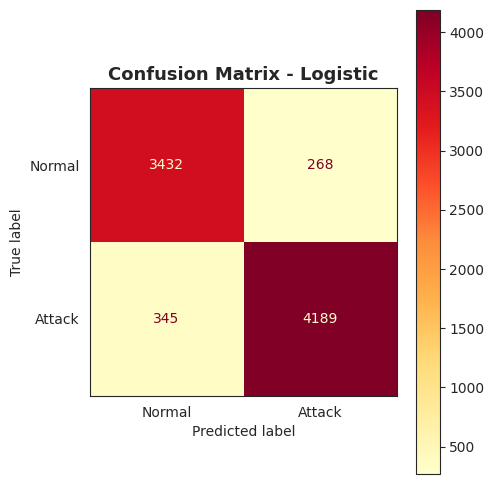

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style('white')

cm = confusion_matrix(y_test, model.predict(X_test))

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap=plt.cm.YlOrRd, ax=ax, colorbar=True)
ax.set_title('Confusion Matrix - Logistic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='4_2'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>kNN</b>

In [ ]:
%%time
from sklearn.neighbors import KNeighborsClassifier
start = time.time()
model = KNeighborsClassifier(n_neighbors=9).fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test) # These are the predictions from the test data.
end_predict = time.time()

CPU times: user 4.62 s, sys: 12.7 ms, total: 4.63 s
Wall time: 6.3 s


In [ ]:
accuracy  = accuracy_score(y_test, y_predictions)
recall    = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s       = f1_score(y_test, y_predictions, average='weighted')
roc_auc   = roc_auc_score(y_test, y_predictions)
mcc       = matthews_corrcoef(y_test, y_predictions)
kappa     = cohen_kappa_score(y_test, y_predictions)

print('Accuracy:    ' + '{:.2%}'.format(accuracy))
print('Recall:      ' + '{:.2%}'.format(recall))
print('Precision:   ' + '{:.2%}'.format(precision))
print('F1-Score:    ' + '{:.2%}'.format(f1s))
print('ROC-AUC:     ' + '{:.4f}'.format(roc_auc))
print('MCC:         ' + '{:.4f}'.format(mcc))
print('Cohen Kappa: ' + '{:.4f}'.format(kappa))
print('time to train:   ' + '{:.2f}'.format(end_train-start) + ' s')
print('time to predict: ' + '{:.2f}'.format(end_predict-end_train) + ' s')
print('total:           ' + '{:.2f}'.format(end_predict-start) + ' s')
print()
print('Classification Report:')
print(classification_report(y_test, y_predictions, target_names=['Normal','Attack']))
model_performance.loc['kNN'] = [
    accuracy, recall, precision, f1s,
    roc_auc, mcc, kappa,
    end_train-start, end_predict-end_train, end_predict-start
]

Accuracy:    94.84%
Recall:      94.84%
Precision:   94.95%
F1-Score:    94.85%
ROC-AUC:     0.9501
MCC:         0.8971
Cohen Kappa: 0.8962
time to train:   0.01 s
time to predict: 6.17 s
total:           6.18 s

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.97      0.94      3700
      Attack       0.97      0.93      0.95      4534

    accuracy                           0.95      8234
   macro avg       0.95      0.95      0.95      8234
weighted avg       0.95      0.95      0.95      8234



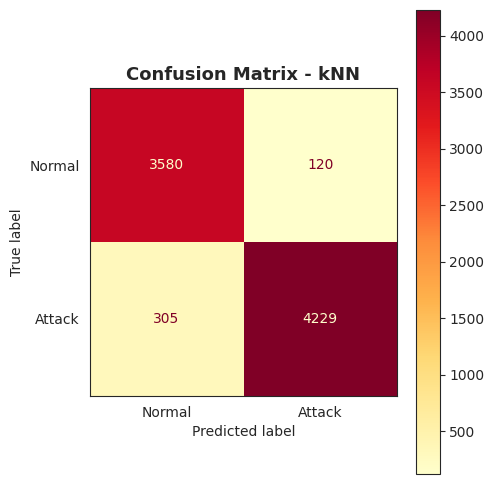

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style('white')

cm = confusion_matrix(y_test, model.predict(X_test))

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap=plt.cm.YlOrRd, ax=ax, colorbar=True)
ax.set_title('Confusion Matrix - kNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='4_3'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Decision Tree</b>


In [ ]:
%%time
from sklearn.tree import DecisionTreeClassifier
start = time.time()
model = DecisionTreeClassifier().fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test) # These are the predictions from the test data.
end_predict = time.time()

CPU times: user 1.46 s, sys: 5.61 ms, total: 1.46 s
Wall time: 1.48 s


In [ ]:
accuracy  = accuracy_score(y_test, y_predictions)
recall    = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s       = f1_score(y_test, y_predictions, average='weighted')
roc_auc   = roc_auc_score(y_test, y_predictions)
mcc       = matthews_corrcoef(y_test, y_predictions)
kappa     = cohen_kappa_score(y_test, y_predictions)

print('Accuracy:    ' + '{:.2%}'.format(accuracy))
print('Recall:      ' + '{:.2%}'.format(recall))
print('Precision:   ' + '{:.2%}'.format(precision))
print('F1-Score:    ' + '{:.2%}'.format(f1s))
print('ROC-AUC:     ' + '{:.4f}'.format(roc_auc))
print('MCC:         ' + '{:.4f}'.format(mcc))
print('Cohen Kappa: ' + '{:.4f}'.format(kappa))
print('time to train:   ' + '{:.2f}'.format(end_train-start) + ' s')
print('time to predict: ' + '{:.2f}'.format(end_predict-end_train) + ' s')
print('total:           ' + '{:.2f}'.format(end_predict-start) + ' s')
print()
print('Classification Report:')
print(classification_report(y_test, y_predictions, target_names=['Normal','Attack']))
model_performance.loc['Decision Tree'] = [
    accuracy, recall, precision, f1s,
    roc_auc, mcc, kappa,
    end_train-start, end_predict-end_train, end_predict-start
]

Accuracy:    96.68%
Recall:      96.68%
Precision:   96.68%
F1-Score:    96.68%
ROC-AUC:     0.9665
MCC:         0.9330
Cohen Kappa: 0.9330
time to train:   1.44 s
time to predict: 0.00 s
total:           1.44 s

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96      3700
      Attack       0.97      0.97      0.97      4534

    accuracy                           0.97      8234
   macro avg       0.97      0.97      0.97      8234
weighted avg       0.97      0.97      0.97      8234



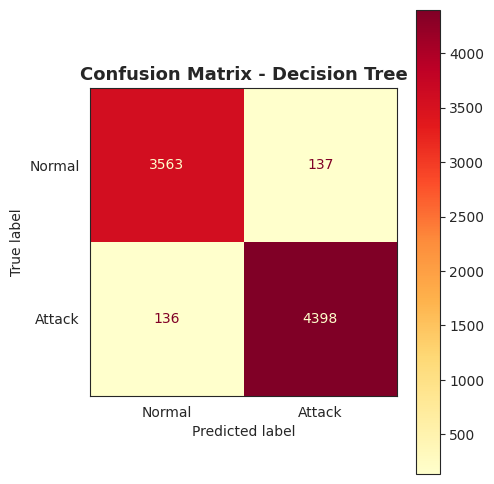

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style('white')

cm = confusion_matrix(y_test, model.predict(X_test))

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap=plt.cm.YlOrRd, ax=ax, colorbar=True)
ax.set_title('Confusion Matrix - Decision Tree', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='4_5'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Random Forest</b>

In [ ]:
%%time
from sklearn.ensemble import RandomForestClassifier
start = time.time()
model = RandomForestClassifier(n_estimators = 600,n_jobs=-1,random_state=42,bootstrap=True,).fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test) # These are the predictions from the test data.
end_predict = time.time()

CPU times: user 2min, sys: 532 ms, total: 2min
Wall time: 1min 13s


In [ ]:
accuracy  = accuracy_score(y_test, y_predictions)
recall    = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s       = f1_score(y_test, y_predictions, average='weighted')
roc_auc   = roc_auc_score(y_test, y_predictions)
mcc       = matthews_corrcoef(y_test, y_predictions)
kappa     = cohen_kappa_score(y_test, y_predictions)

print('Accuracy:    ' + '{:.2%}'.format(accuracy))
print('Recall:      ' + '{:.2%}'.format(recall))
print('Precision:   ' + '{:.2%}'.format(precision))
print('F1-Score:    ' + '{:.2%}'.format(f1s))
print('ROC-AUC:     ' + '{:.4f}'.format(roc_auc))
print('MCC:         ' + '{:.4f}'.format(mcc))
print('Cohen Kappa: ' + '{:.4f}'.format(kappa))
print('time to train:   ' + '{:.2f}'.format(end_train-start) + ' s')
print('time to predict: ' + '{:.2f}'.format(end_predict-end_train) + ' s')
print('total:           ' + '{:.2f}'.format(end_predict-start) + ' s')
print()
print('Classification Report:')
print(classification_report(y_test, y_predictions, target_names=['Normal','Attack']))
model_performance.loc['Random Forest'] = [
    accuracy, recall, precision, f1s,
    roc_auc, mcc, kappa,
    end_train-start, end_predict-end_train, end_predict-start
]

Accuracy:    97.70%
Recall:      97.70%
Precision:   97.71%
F1-Score:    97.71%
ROC-AUC:     0.9771
MCC:         0.9537
Cohen Kappa: 0.9536
time to train:   72.80 s
time to predict: 0.45 s
total:           73.25 s

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97      3700
      Attack       0.98      0.98      0.98      4534

    accuracy                           0.98      8234
   macro avg       0.98      0.98      0.98      8234
weighted avg       0.98      0.98      0.98      8234



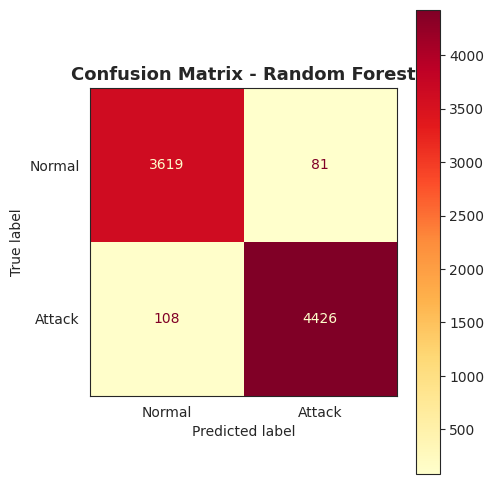

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style('white')

cm = confusion_matrix(y_test, model.predict(X_test))

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap=plt.cm.YlOrRd, ax=ax, colorbar=True)
ax.set_title('Confusion Matrix - Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='4_6'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Gradient Boosting Classifier</b>

In [ ]:
%%time
from sklearn.ensemble import GradientBoostingClassifier
start = time.time()
model = GradientBoostingClassifier().fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test) # These are the predictions from the test data.
end_predict = time.time()

CPU times: user 47.7 s, sys: 52.7 ms, total: 47.8 s
Wall time: 48.2 s


In [ ]:
accuracy  = accuracy_score(y_test, y_predictions)
recall    = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s       = f1_score(y_test, y_predictions, average='weighted')
roc_auc   = roc_auc_score(y_test, y_predictions)
mcc       = matthews_corrcoef(y_test, y_predictions)
kappa     = cohen_kappa_score(y_test, y_predictions)

print('Accuracy:    ' + '{:.2%}'.format(accuracy))
print('Recall:      ' + '{:.2%}'.format(recall))
print('Precision:   ' + '{:.2%}'.format(precision))
print('F1-Score:    ' + '{:.2%}'.format(f1s))
print('ROC-AUC:     ' + '{:.4f}'.format(roc_auc))
print('MCC:         ' + '{:.4f}'.format(mcc))
print('Cohen Kappa: ' + '{:.4f}'.format(kappa))
print('time to train:   ' + '{:.2f}'.format(end_train-start) + ' s')
print('time to predict: ' + '{:.2f}'.format(end_predict-end_train) + ' s')
print('total:           ' + '{:.2f}'.format(end_predict-start) + ' s')
print()
print('Classification Report:')
print(classification_report(y_test, y_predictions, target_names=['Normal','Attack']))
model_performance.loc['Gradient Boosting Classifier'] = [
    accuracy, recall, precision, f1s,
    roc_auc, mcc, kappa,
    end_train-start, end_predict-end_train, end_predict-start
]

Accuracy:    95.73%
Recall:      95.73%
Precision:   95.73%
F1-Score:    95.73%
ROC-AUC:     0.9572
MCC:         0.9137
Cohen Kappa: 0.9137
time to train:   48.21 s
time to predict: 0.02 s
total:           48.23 s

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.96      0.95      3700
      Attack       0.96      0.96      0.96      4534

    accuracy                           0.96      8234
   macro avg       0.96      0.96      0.96      8234
weighted avg       0.96      0.96      0.96      8234



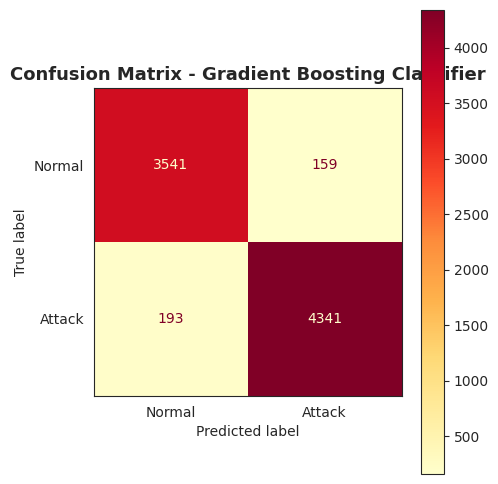

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style('white')

cm = confusion_matrix(y_test, model.predict(X_test))

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap=plt.cm.YlOrRd, ax=ax, colorbar=True)
ax.set_title('Confusion Matrix - Gradient Boosting Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='4_7'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Neural Network MLP</b>

In [ ]:
%%time
from sklearn.neural_network import MLPClassifier
start = time.time()
model = MLPClassifier(hidden_layer_sizes = (20,20,),
                      activation='relu',
                      solver='adam',
                      batch_size=1000,
                      verbose=0).fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test) # These are the predictions from the test data.
end_predict = time.time()

CPU times: user 58 s, sys: 180 ms, total: 58.2 s
Wall time: 35 s


In [ ]:
accuracy  = accuracy_score(y_test, y_predictions)
recall    = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s       = f1_score(y_test, y_predictions, average='weighted')
roc_auc   = roc_auc_score(y_test, y_predictions)
mcc       = matthews_corrcoef(y_test, y_predictions)
kappa     = cohen_kappa_score(y_test, y_predictions)

print('Accuracy:    ' + '{:.2%}'.format(accuracy))
print('Recall:      ' + '{:.2%}'.format(recall))
print('Precision:   ' + '{:.2%}'.format(precision))
print('F1-Score:    ' + '{:.2%}'.format(f1s))
print('ROC-AUC:     ' + '{:.4f}'.format(roc_auc))
print('MCC:         ' + '{:.4f}'.format(mcc))
print('Cohen Kappa: ' + '{:.4f}'.format(kappa))
print('time to train:   ' + '{:.2f}'.format(end_train-start) + ' s')
print('time to predict: ' + '{:.2f}'.format(end_predict-end_train) + ' s')
print('total:           ' + '{:.2f}'.format(end_predict-start) + ' s')
print()
print('Classification Report:')
print(classification_report(y_test, y_predictions, target_names=['Normal','Attack']))
model_performance.loc['MLP'] = [
    accuracy, recall, precision, f1s,
    roc_auc, mcc, kappa,
    end_train-start, end_predict-end_train, end_predict-start
]

Accuracy:    96.67%
Recall:      96.67%
Precision:   96.67%
F1-Score:    96.67%
ROC-AUC:     0.9666
MCC:         0.9328
Cohen Kappa: 0.9328
time to train:   35.02 s
time to predict: 0.01 s
total:           35.03 s

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.96      3700
      Attack       0.97      0.97      0.97      4534

    accuracy                           0.97      8234
   macro avg       0.97      0.97      0.97      8234
weighted avg       0.97      0.97      0.97      8234



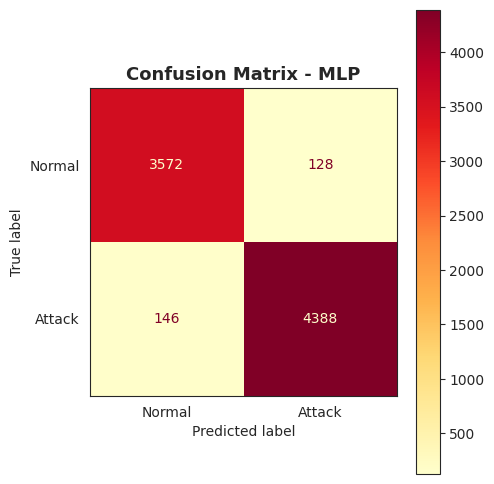

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style('white')

cm = confusion_matrix(y_test, model.predict(X_test))

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap=plt.cm.YlOrRd, ax=ax, colorbar=True)
ax.set_title('Confusion Matrix - MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='4_8'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Support Vector Machine (SVM)</b>

In [ ]:
%%time
from sklearn.svm import SVC
start = time.time()
model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
model.fit(X_train, y_train)
end_train = time.time()
y_predictions = model.predict(X_test)
end_predict = time.time()

CPU times: user 11min 40s, sys: 1.47 s, total: 11min 42s
Wall time: 11min 48s


In [ ]:
accuracy  = accuracy_score(y_test, y_predictions)
recall    = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s       = f1_score(y_test, y_predictions, average='weighted')
roc_auc   = roc_auc_score(y_test, y_predictions)
mcc       = matthews_corrcoef(y_test, y_predictions)
kappa     = cohen_kappa_score(y_test, y_predictions)

print('Accuracy:    ' + '{:.2%}'.format(accuracy))
print('Recall:      ' + '{:.2%}'.format(recall))
print('Precision:   ' + '{:.2%}'.format(precision))
print('F1-Score:    ' + '{:.2%}'.format(f1s))
print('ROC-AUC:     ' + '{:.4f}'.format(roc_auc))
print('MCC:         ' + '{:.4f}'.format(mcc))
print('Cohen Kappa: ' + '{:.4f}'.format(kappa))
print('time to train:   ' + '{:.2f}'.format(end_train-start) + ' s')
print('time to predict: ' + '{:.2f}'.format(end_predict-end_train) + ' s')
print('total:           ' + '{:.2f}'.format(end_predict-start) + ' s')
print()
print('Classification Report:')
print(classification_report(y_test, y_predictions, target_names=['Normal','Attack']))
model_performance.loc['SVM'] = [
    accuracy, recall, precision, f1s,
    roc_auc, mcc, kappa,
    end_train-start, end_predict-end_train, end_predict-start
]

Accuracy:    94.91%
Recall:      94.91%
Precision:   95.03%
F1-Score:    94.92%
ROC-AUC:     0.9509
MCC:         0.8986
Cohen Kappa: 0.8976
time to train:   696.47 s
time to predict: 11.72 s
total:           708.19 s

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.97      0.94      3700
      Attack       0.97      0.93      0.95      4534

    accuracy                           0.95      8234
   macro avg       0.95      0.95      0.95      8234
weighted avg       0.95      0.95      0.95      8234



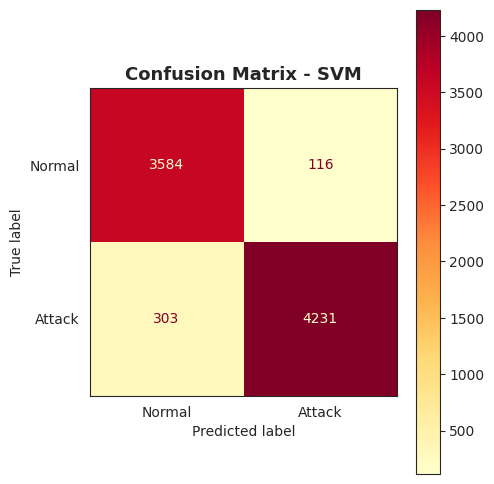

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style('white')

cm = confusion_matrix(y_test, model.predict(X_test))

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap=plt.cm.YlOrRd, ax=ax, colorbar=True)
ax.set_title('Confusion Matrix - SVM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='4_9'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>XGBoost Classifier</b>

In [ ]:
%%time
# Install xgboost if not already installed
# !pip install xgboost -q
from xgboost import XGBClassifier
start = time.time()
model = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                      use_label_encoder=False, eval_metric='logloss',
                      n_jobs=-1, random_state=42)
model.fit(X_train, y_train)
end_train = time.time()
y_predictions = model.predict(X_test)
end_predict = time.time()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:05:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CPU times: user 6.94 s, sys: 306 ms, total: 7.24 s
Wall time: 4.14 s


In [ ]:
accuracy  = accuracy_score(y_test, y_predictions)
recall    = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s       = f1_score(y_test, y_predictions, average='weighted')
roc_auc   = roc_auc_score(y_test, y_predictions)
mcc       = matthews_corrcoef(y_test, y_predictions)
kappa     = cohen_kappa_score(y_test, y_predictions)

print('Accuracy:    ' + '{:.2%}'.format(accuracy))
print('Recall:      ' + '{:.2%}'.format(recall))
print('Precision:   ' + '{:.2%}'.format(precision))
print('F1-Score:    ' + '{:.2%}'.format(f1s))
print('ROC-AUC:     ' + '{:.4f}'.format(roc_auc))
print('MCC:         ' + '{:.4f}'.format(mcc))
print('Cohen Kappa: ' + '{:.4f}'.format(kappa))
print('time to train:   ' + '{:.2f}'.format(end_train-start) + ' s')
print('time to predict: ' + '{:.2f}'.format(end_predict-end_train) + ' s')
print('total:           ' + '{:.2f}'.format(end_predict-start) + ' s')
print()
print('Classification Report:')
print(classification_report(y_test, y_predictions, target_names=['Normal','Attack']))
model_performance.loc['XGBoost'] = [
    accuracy, recall, precision, f1s,
    roc_auc, mcc, kappa,
    end_train-start, end_predict-end_train, end_predict-start
]

Accuracy:    97.79%
Recall:      97.79%
Precision:   97.80%
F1-Score:    97.79%
ROC-AUC:     0.9782
MCC:         0.9554
Cohen Kappa: 0.9554
time to train:   3.84 s
time to predict: 0.04 s
total:           3.88 s

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      3700
      Attack       0.98      0.98      0.98      4534

    accuracy                           0.98      8234
   macro avg       0.98      0.98      0.98      8234
weighted avg       0.98      0.98      0.98      8234



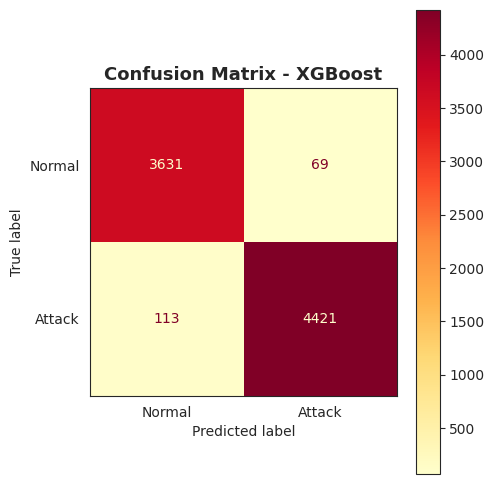

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style('white')

cm = confusion_matrix(y_test, model.predict(X_test))

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap=plt.cm.YlOrRd, ax=ax, colorbar=True)
ax.set_title('Confusion Matrix - XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

,Accuracy,Recall,Precision,F1-Score,ROC-AUC,MCC,Cohen Kappa,time to train,time to predict,total time
Logistic,92.5553%,92.5553%,92.5844%,92.5617%,0.9257,0.8500,0.8498,1.8503,0.0011,1.8514
kNN,94.8385%,94.8385%,94.9529%,94.8477%,0.9501,0.8971,0.8962,0.0052,6.1724,6.1776
Decision Tree,96.6845%,96.6845%,96.6844%,96.6844%,0.9665,0.9330,0.9330,1.4388,0.0019,1.4407
Random Forest,97.7046%,97.7046%,97.7082%,97.7054%,0.9771,0.9537,0.9536,72.8006,0.4491,73.2497
Gradient Boosting Classifier,95.7250%,95.7250%,95.7318%,95.7268%,0.9572,0.9137,0.9137,48.2115,0.0175,48.2290
MLP,96.6723%,96.6723%,96.6747%,96.6731%,0.9666,0.9328,0.9328,35.0210,0.0054,35.0264
SVM,94.9113%,94.9113%,95.0278%,94.9205%,0.9509,0.8986,0.8976,696.4689,11.7179,708.1868
XGBoost,97.7897%,97.7897%,97.7976%,97.7908%,0.9782,0.9554,0.9554,3.8374,0.0417,3.8791


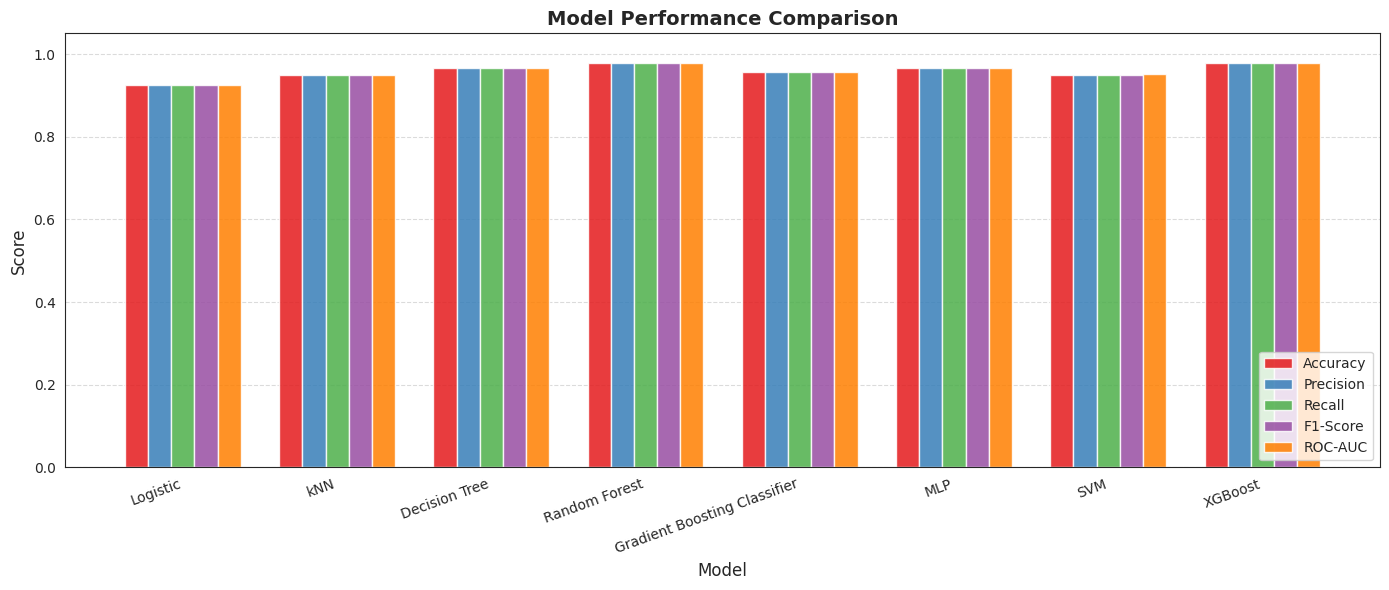

/tmp/ipykernel_1896/3634709136.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(models, rotation=25, ha='right', fontsize=9)
/tmp/ipykernel_1896/3634709136.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(models, rotation=25, ha='right', fontsize=9)


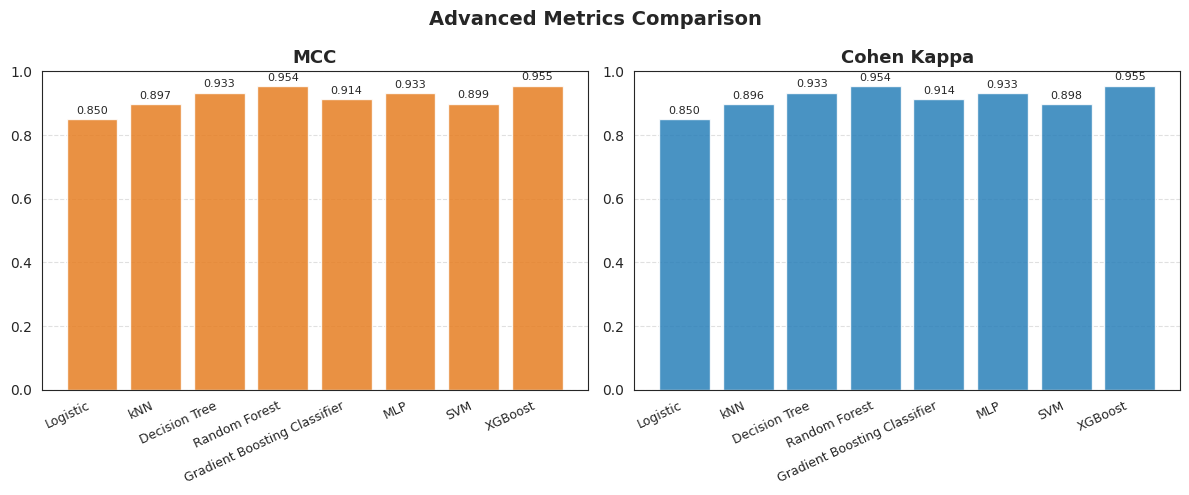

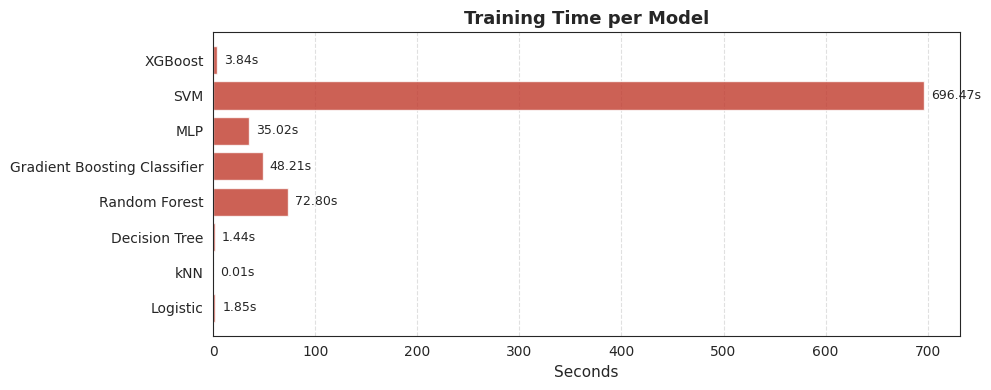

In [ ]:
# ─── Summary Table ───────────────────────────────────────────────────────────
styled = model_performance.style \
    .background_gradient(cmap='YlOrRd', subset=['Accuracy','Recall','Precision','F1-Score','ROC-AUC','MCC','Cohen Kappa']) \
    .background_gradient(cmap='Blues_r', subset=['time to train','time to predict','total time']) \
    .format({
        'Accuracy':       '{:.4%}',
        'Precision':      '{:.4%}',
        'Recall':         '{:.4%}',
        'F1-Score':       '{:.4%}',
        'ROC-AUC':        '{:.4f}',
        'MCC':            '{:.4f}',
        'Cohen Kappa':    '{:.4f}',
        'time to train':  '{:.4f}',
        'time to predict':'{:.4f}',
        'total time':     '{:.4f}',
    })
display(styled)

# ─── Bar Chart Comparison ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models = model_performance.index.tolist()
x = np.arange(len(models))
width = 0.15
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    vals = model_performance[metric].astype(float).values
    bars = ax.bar(x + i*width, vals, width, label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width*2)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ─── MCC & Cohen Kappa comparison ─────────────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax2, metric, color in zip(axes, ['MCC','Cohen Kappa'], ['#e67e22','#2980b9']):
    vals = model_performance[metric].astype(float).values
    bars = ax2.bar(models, vals, color=color, alpha=0.85, edgecolor='white')
    ax2.set_title(metric, fontsize=13, fontweight='bold')
    ax2.set_xticklabels(models, rotation=25, ha='right', fontsize=9)
    ax2.set_ylim(0, 1.0)
    ax2.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax2.set_axisbelow(True)
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Advanced Metrics Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Training Time comparison ─────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(10, 4))
train_times = model_performance['time to train'].astype(float).values
bars = ax3.barh(models, train_times, color='#c0392b', alpha=0.8, edgecolor='white')
ax3.set_xlabel('Seconds', fontsize=11)
ax3.set_title('Training Time per Model', fontsize=13, fontweight='bold')
for bar, v in zip(bars, train_times):
    ax3.text(v + max(train_times)*0.01, bar.get_y()+bar.get_height()/2,
             f'{v:.2f}s', va='center', fontsize=9)
ax3.xaxis.grid(True, linestyle='--', alpha=0.6)
ax3.set_axisbelow(True)
plt.tight_layout()
plt.show()